RANDOM FOREST MODEL

In [35]:
#importing important libraries
import numpy as np
import pandas as pd  
import seaborn as sns
import matplotlib.pyplot as plt
import json
import pandas as pd_inner
import os

In [36]:
#importing randomforest, metrics from sklearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    confusion_matrix, roc_curve, classification_report
)

In [37]:
#loading dataset
df = pd.read_csv('../../cleaned_data/titanic_featured.csv')

In [38]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Family_Size,is_alone,Age_x_Pclass,FarePerPerson,AgeGroup
0,0,3,1,22.0,1,0,7.2500,0.0,2,0,66.0,3.62500,2
1,1,1,0,38.0,1,0,71.2833,1.0,2,0,38.0,35.64165,3
2,1,3,0,26.0,0,0,7.9250,0.0,1,1,78.0,7.92500,2
3,1,1,0,35.0,1,0,53.1000,0.0,2,0,35.0,26.55000,2
4,0,3,1,35.0,0,0,8.0500,0.0,1,1,105.0,8.05000,2


In [39]:
#creating and training random forest model
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    random_state=42
)
model_rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:
#making predictions
y_pred = model_rf.predict(X_test)
y_prob = model_rf.predict_proba(X_test)[:, 1]

In [41]:
#counting model accuracy
accuracy = accuracy_score(y_test, y_pred)
auc      = roc_auc_score(y_test, y_prob)
cv_score = cross_val_score(model_rf, X_train, y_train, cv=5).mean()

print(f'  Accuracy : {accuracy:.4f} ({accuracy*100:.1f}%)')
print(f'  ROC-AUC  : {auc:.4f}')
print(f'  CV Score : {cv_score:.4f}')
print(classification_report(y_test, y_pred, target_names=['Died', 'Survived']))

  Accuracy : 0.7933 (79.3%)
  ROC-AUC  : 0.8466
  CV Score : 0.8189
              precision    recall  f1-score   support

        Died       0.80      0.88      0.84       110
    Survived       0.78      0.65      0.71        69

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.77       179
weighted avg       0.79      0.79      0.79       179



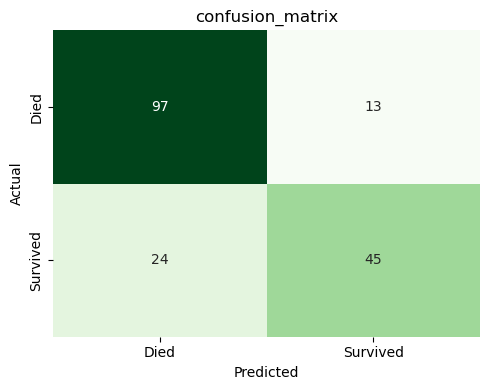

In [42]:
#confusion matrix
fig, ax = plt.subplots(figsize=(5,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            ax=ax,
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'],
            cbar=False)
ax.set_title('confusion_matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

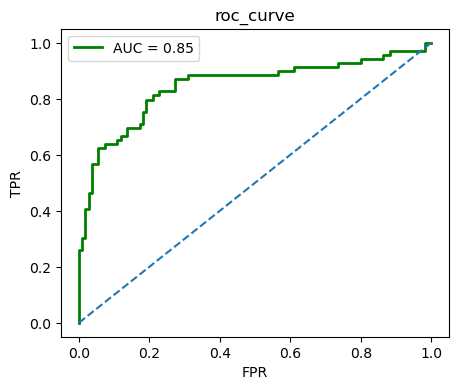

In [43]:
#roc_curve
fig, ax = plt.subplots(figsize=(5,4))
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax.plot(fpr, tpr, lw=2, color='green', label=f'AUC = {auc:.2f}')
ax.plot([0, 1], [0, 1], linestyle='--')
ax.set_title('roc_curve')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.legend()
plt.show()

FEATURE IMPORTANCE

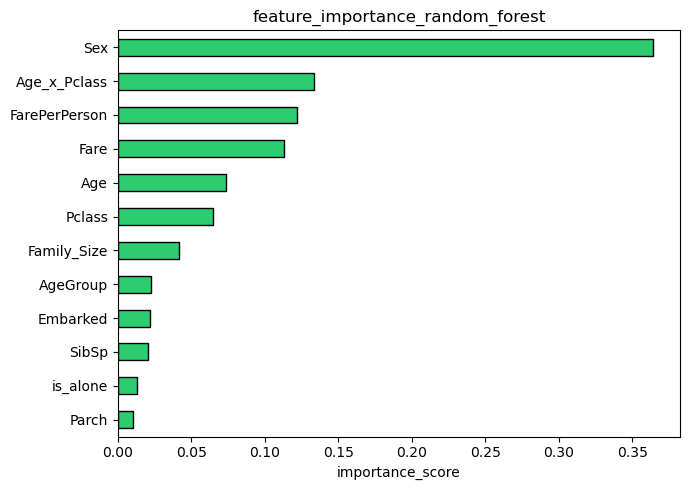

In [44]:
#feature importance from random forest
feat_imp = pd.Series(
    model_rf.feature_importances_,
    index=X.columns if hasattr(X, 'columns') else [f'f{i}' for i in range(X_train.shape[1])]
).sort_values(ascending=True)

plt.figure(figsize=(7,5))
feat_imp.plot(kind='barh', color='#2ecc71', edgecolor='black')
plt.title('feature_importance_random_forest')
plt.xlabel('importance_score')
plt.tight_layout()
plt.show()

In [45]:
#saving model result in json for comparison with model trained using Logistic regression
 

results['random_forest'] = {
    'accuracy': round(accuracy, 4),
    'roc_auc':  round(auc, 4),
    'cv_score': round(cv_score, 4)
}

os.makedirs('results', exist_ok=True)

with open('results/random_forest.json', 'w') as f:
    json.dump(results, f)